# Graph creation and UMAP visualization

This notebook builds structural EEG graphs from per-channel features, visualizes electrode layouts, and generates UMAP embeddings of graph-level representations.

Sections:\n- Setup & imports\n- Load and clean features\n- Build epoch tensors (nodes/features)\n- Create structural graph and visualize topology\n- UMAP visualizations (global / per-subject)

In [1]:
# Setup and imports
import sys
from pathlib import Path
import os
import json

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
# Project root detection (works when running from notebooks/ folder)
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))
print(f"Project root: {project_root}")

Project root: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech


In [2]:
# Load feature dataframe and basic cleaning
df_features_path = project_root / "data/processed/comprehensive_features_subjects.csv"
if not df_features_path.exists():
    raise FileNotFoundError(f"Features file not found: {df_features_path}")

df_features = pd.read_csv(df_features_path)
print(f"✓ Loaded comprehensive features from {df_features_path} ({len(df_features)} rows)")

# Ensure subject/session/epoch numeric
for col in ["subject_id", "session_id", "epoch_idx"]:
    df_features[col] = pd.to_numeric(df_features[col], errors="coerce")
before_drop = len(df_features)
df_features = df_features.dropna(subset=["subject_id", "session_id", "epoch_idx"])
print(f"✓ Dropped {before_drop - len(df_features)} rows with non-numeric subject/session/epoch")
df_features[["subject_id", "session_id", "epoch_idx"]] = df_features[["subject_id", "session_id", "epoch_idx"]].astype(int)

/var/folders/nf/98xxwv1511dfz5j4f3x3jqgc0000gn/T/ipykernel_18962/4141011067.py:6: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_features = pd.read_csv(df_features_path)


✓ Loaded comprehensive features from /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/processed/comprehensive_features_subjects.csv (2361066 rows)
✓ Dropped 8784 rows with non-numeric subject/session/epoch


In [3]:
# Channel mapping and label alignment
channel_map_path = project_root / "data/interim/channel_mapping.csv"
if not channel_map_path.exists():
    raise FileNotFoundError(f"Channel mapping file not found: {channel_map_path}")
mapping = pd.read_csv(channel_map_path)
required_cols = {"h5_name", "eloc_name"}
if not required_cols.issubset(set(mapping.columns)):
    raise ValueError(f"channel_mapping.csv must contain columns {required_cols}, found {mapping.columns.tolist()}")
map_dict = dict(zip(mapping["h5_name"], mapping["eloc_name"]))
df_features["channel_std"] = df_features["channel"].map(map_dict)
before_drop_ch = len(df_features)
df_features = df_features.dropna(subset=["channel_std"])
print(f"✓ Dropped {before_drop_ch - len(df_features)} rows with unmapped channels")

# Load label2idx and derive label_word
label2idx_path = project_root / "data/interim/label2idx.json"
if not label2idx_path.exists():
    raise FileNotFoundError(f"Label2idx file not found: {label2idx_path}")
with open(label2idx_path, "r") as f:
    label2idx = json.load(f)
idx2label = {v: k for k, v in label2idx.items()}
df_features["label_word"] = df_features["label_name"].str.replace("_img$", "", regex=True)
df_features["label_id"] = df_features["label_word"].map(label2idx)
missing_label_ids = df_features["label_id"].isna().sum()
if missing_label_ids > 0:
    missing_words = df_features.loc[df_features["label_id"].isna(), "label_word"].unique().tolist()
    print("⚠ WARNING:", missing_label_ids, "rows with label_word not found in label2idx.")
    print("Missing words:", missing_words)
before_drop_lbl = len(df_features)
df_features = df_features.dropna(subset=["label_id"])
print(f"✓ Dropped {before_drop_lbl - len(df_features)} rows with unknown labels")
df_features["label_id"] = df_features["label_id"].astype(int)

✓ Dropped 0 rows with unmapped channels
✓ Dropped 0 rows with unknown labels


In [4]:
# Build epoch-level tensors: X_epochs, y_epochs, meta_epochs
out_path = project_root / "data/processed/eeg_epoch_tensors.pt"

if out_path.exists():
    print(f"Tensor file already exists at {out_path}. Loading...")
    data = torch.load(out_path)
    X_epochs = data["X_epochs"]
    y_epochs = data["y_epochs"]
    if isinstance(y_epochs, torch.Tensor):
        y_epochs = y_epochs.tolist()
    meta_epochs = data["meta_epochs"]
    feature_cols = data["feature_cols"]
    print(f"✓ Loaded {len(X_epochs)} epoch tensors")
else:
    print(f"Tensor file not found. Creating...")
    group_cols = ["subject_id", "session_id", "epoch_idx"]
    df_sorted = df_features.sort_values(group_cols + ["channel_std"])
    meta_cols = ["subject_id", "session_id", "epoch_idx", "channel", "channel_std", "label_name", "label_word", "label_id"]
    feature_cols = [c for c in df_features.columns if c not in meta_cols]
    X_epochs = []
    y_epochs = []
    meta_epochs = []
    for keys, g in df_sorted.groupby(group_cols):
        subject_id, session_id, epoch_idx = keys
        x_np = g[feature_cols].values
        x = torch.tensor(x_np, dtype=torch.float32)
        label_id = int(g["label_id"].iloc[0])
        X_epochs.append(x)
        y_epochs.append(label_id)
        meta_epochs.append({"subject_id": int(subject_id), "session_id": int(session_id), "epoch_idx": int(epoch_idx)})
    print(f"✓ Built {len(X_epochs)} epoch tensors")
    print("First epoch shape:", X_epochs[0].shape)
    
    # Save tensors
    out_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"X_epochs": X_epochs, "y_epochs": torch.tensor(y_epochs, dtype=torch.long), "meta_epochs": meta_epochs, "feature_cols": feature_cols, "label2idx": label2idx}, out_path)
    print(f"✓ Saved epoch tensors to {out_path}")

Tensor file already exists at /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/data/processed/eeg_epoch_tensors.pt. Loading...
✓ Loaded 38562 epoch tensors


In [5]:
# Saving is now handled in the previous cell to avoid re-computation
pass

In [6]:
out_path = project_root / "data/processed/eeg_epoch_tensors.pt"

torch.load(out_path)  # Test loading
print("✓ Successfully loaded saved epoch tensors")

✓ Successfully loaded saved epoch tensors


## UMAP of graphs

We flatten each graph (nodes x features) into a long vector and embed with UMAP. For large datasets, we sample a subset.

In [7]:
!pip install umap-learn

Num graphs totali: 38562


/opt/homebrew/Caskroom/miniconda/base/envs/daniele_310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


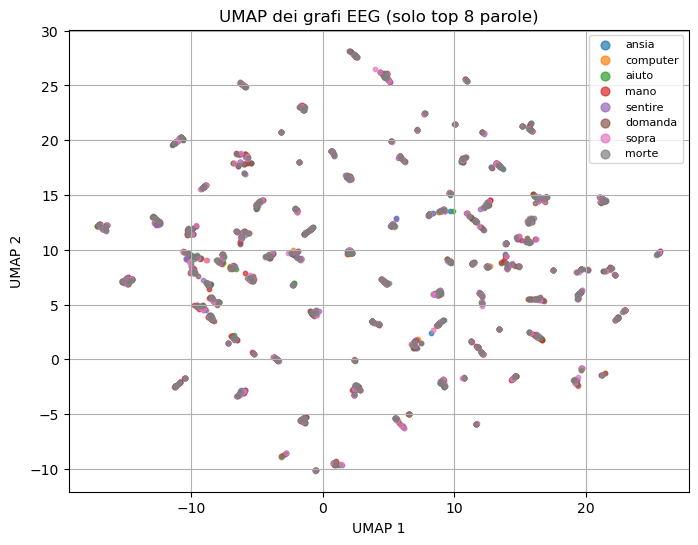

In [8]:
# UMAP embedding of graph-level vectors
import umap
from sklearn.preprocessing import StandardScaler
from collections import Counter
num_graphs = len(X_epochs)
print("Num graphs totali:", num_graphs)
max_samples = 38562
idx = np.random.choice(num_graphs, size=min(max_samples, num_graphs), replace=False)
X_flat = []
y_flat = []
for i in idx:
    x = X_epochs[i]
    x_vec = x.reshape(-1).numpy()
    X_flat.append(x_vec)
    y_flat.append(y_epochs[i])
X_flat = np.stack(X_flat, axis=0)
y_flat = np.array(y_flat)
scaler = StandardScaler()
X_flat_scaled = scaler.fit_transform(X_flat)
umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_flat_scaled)
labels_text = np.array([idx2label[int(y)] for y in y_flat])
cnt = Counter(labels_text)
top_words = [w for w, _ in cnt.most_common(8)]
plt.figure(figsize=(8, 6))
for w in top_words:
    m = labels_text == w
    plt.scatter(X_umap[m, 0], X_umap[m, 1], s=10, alpha=0.7, label=w)
plt.legend(markerscale=2, fontsize=8)
plt.title("UMAP dei grafi EEG (solo top 8 parole)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.show()

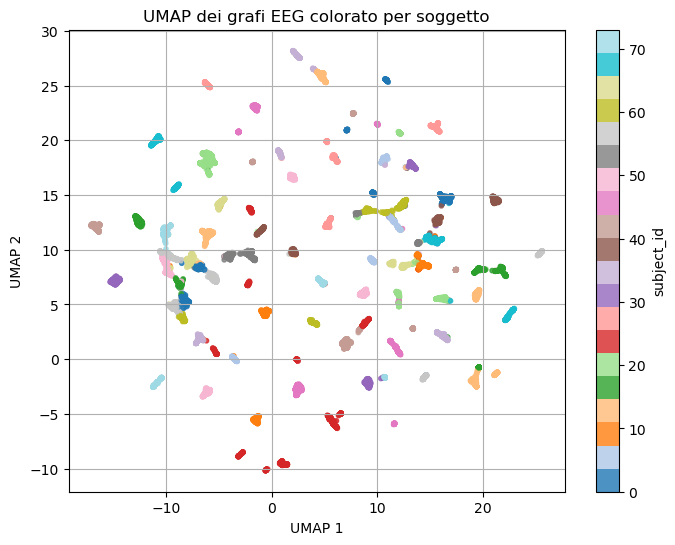

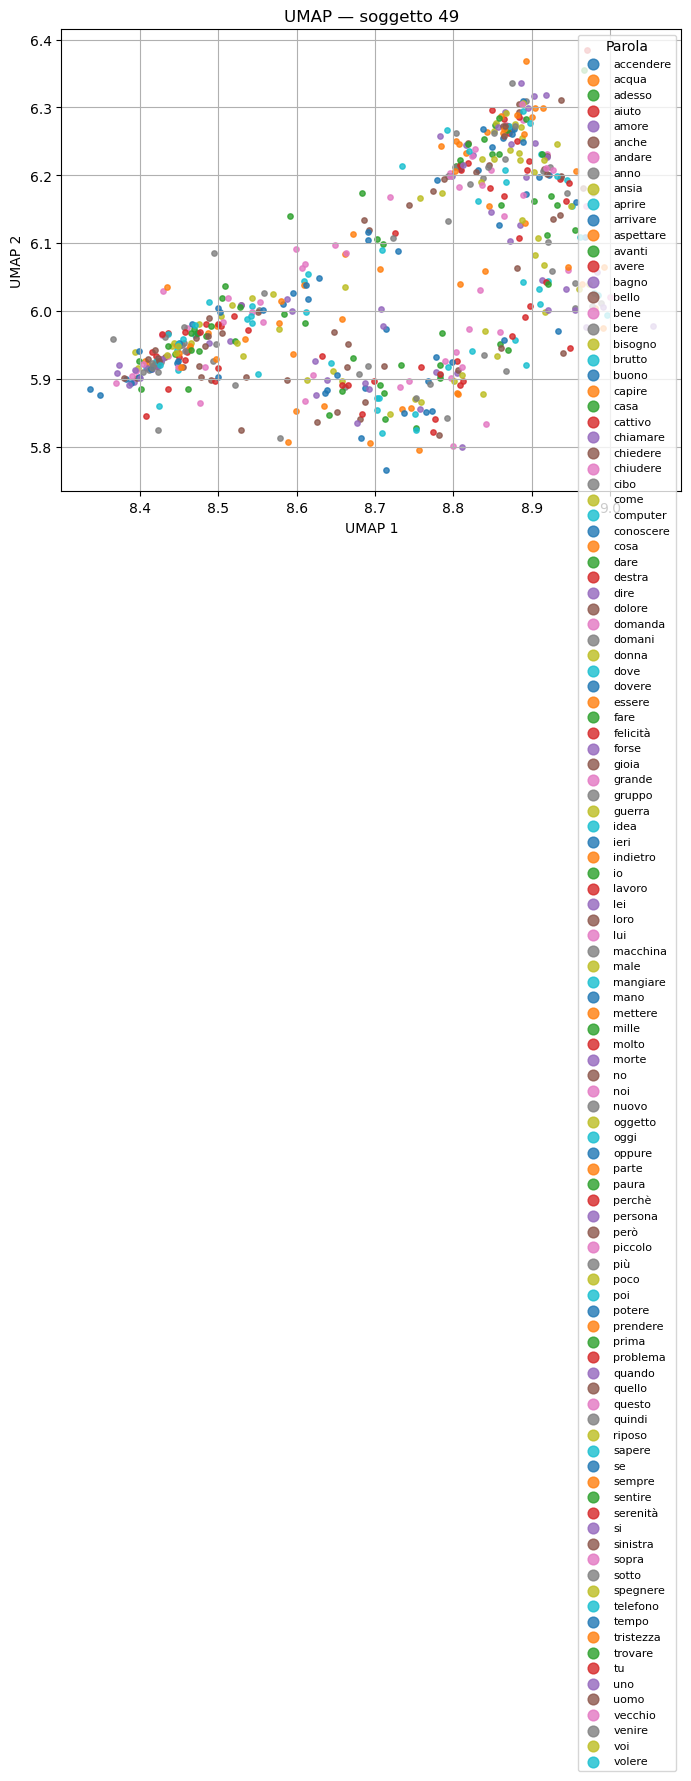

In [9]:
# Color by subject and per-subject view
subjects = np.array([meta_epochs[i]["subject_id"] for i in idx])
plt.figure(figsize=(8, 6))
sc = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=subjects, cmap="tab20", s=10, alpha=0.8)
plt.colorbar(sc, label="subject_id")
plt.title("UMAP dei grafi EEG colorato per soggetto")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.show()

# Per-subject example (change subject_target as needed)
subject_target = subjects[0]
mask = subjects == subject_target
plt.figure(figsize=(8, 6))
for w in np.unique(labels_text[mask]):
    m = mask & (labels_text == w)
    plt.scatter(X_umap[m, 0], X_umap[m, 1], s=15, alpha=0.8, label=w)
plt.legend(markerscale=2, fontsize=8, title="Parola",loc="best")
plt.title(f"UMAP — soggetto {subject_target}")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.show()

## Structural Graph

Create a structural graph based on electrode positions (k-NN). Visualize the montage and the resulting graph.

<DigMontage | 0 extras (headshape), 0 HPIs, 0 fiducials, 63 channels>
['A1', 'AF7', 'AF3', 'Fp1', 'FP2', 'AF4', 'AF8', 'A2', 'F7', 'F5']
3 duplicate electrode labels found:
A1/A2, A1/Cz, A2/Cz
Plotting 60 unique labels.


/var/folders/nf/98xxwv1511dfz5j4f3x3jqgc0000gn/T/ipykernel_18962/3092496467.py:7: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  mne.viz.plot_montage(montage, show_names=True)


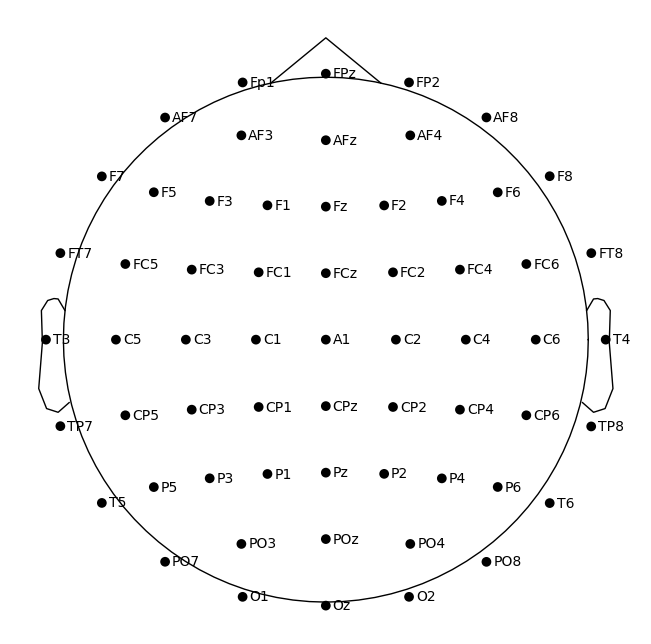

Name mapping: {'A1': 'A1', 'A2': 'A2', 'AF3': 'AF3', 'AF4': 'AF4', 'AF7': 'AF7', 'AF8': 'AF8', 'AFz': 'AFz', 'C1': 'C1', 'C2': 'C2', 'C3': 'C3', 'C4': 'C4', 'C5': 'C5', 'C6': 'C6', 'CP1': 'CP1', 'CP2': 'CP2', 'CP3': 'CP3', 'CP4': 'CP4', 'CP5': 'CP5', 'CP6': 'CP6', 'CPz': 'CPz', 'Cz': 'Cz', 'F1': 'F1', 'F2': 'F2', 'F3': 'F3', 'F4': 'F4', 'F5': 'F5', 'F6': 'F6', 'F7': 'F7', 'F8': 'F8', 'FC1': 'FC1', 'FC2': 'FC2', 'FC3': 'FC3', 'FC4': 'FC4', 'FC5': 'FC5', 'FC6': 'FC6', 'FCz': 'FCz', 'FP2': 'FP2', 'FPz': 'FPz', 'FT7': 'FT7', 'FT8': 'FT8', 'Fp1': 'Fp1', 'Fz': 'Fz', 'O1': 'O1', 'O2': 'O2', 'Oz': 'Oz', 'P1': 'P1', 'P2': 'P2', 'P3': 'P3', 'P4': 'P4', 'P5': 'P5', 'P6': 'P6', 'PO3': 'PO3', 'PO4': 'PO4', 'PO7': 'PO7', 'PO8': 'PO8', 'T3': 'T3', 'T4': 'T4', 'T5': 'T5', 'T6': 'T6', 'TP7': 'TP7', 'TP8': 'TP8'}
Missing: []
coords shape: (61, 3)


In [10]:
# Montage and channel coordinates
import mne
eloc_path = project_root / "src/io/ebneuro.locs"
montage = mne.channels.read_custom_montage(str(eloc_path))
print(montage)
print(montage.ch_names[:10])
mne.viz.plot_montage(montage, show_names=True)

channels_order = sorted(df_features["channel_std"].unique())
pos_dict = montage.get_positions()["ch_pos"]
name_map = {}
missing = []
for ch in channels_order:
    found = [m for m in pos_dict.keys() if m.lower() == ch.lower()]
    if found:
        name_map[ch] = found[0]
    else:
        missing.append(ch)
print("Name mapping:", name_map)
print("Missing:", missing)
channels_used = list(name_map.keys())
coords = np.stack([pos_dict[name_map[ch]] for ch in channels_used])
print("coords shape:", coords.shape)

In [11]:
# Build structural edge index (k-NN)
from sklearn.metrics import pairwise_distances
import torch
def build_structural_edge_index(coords, k=4):
    D = pairwise_distances(coords)
    n = len(coords)
    edges = set()
    for i in range(n):
        nn = np.argsort(D[i])[1:k+1]
        for j in nn:
            edges.add(tuple(sorted((i, j))))
    src, dst = [], []
    for a, b in edges:
        src += [a, b]
        dst += [b, a]
    return torch.tensor([src, dst], dtype=torch.long)
edge_index = build_structural_edge_index(coords, k=4)
print("edge_index:", edge_index.shape)

edge_index: torch.Size([2, 276])


In [12]:
# Create PyG Data objects (one per epoch)
# Install torch-geometric in the environment if needed (outside notebook prefer conda)
from torch_geometric.data import Data
graphs = []
for X, y, meta in zip(X_epochs, y_epochs, meta_epochs):
    g = Data(x=X, edge_index=edge_index, y=torch.tensor([y]))
    graphs.append(g)
print("Num graphs:", len(graphs))
print(graphs[0])

Num graphs: 38562
Data(x=[61, 40], edge_index=[2, 276], y=[1])


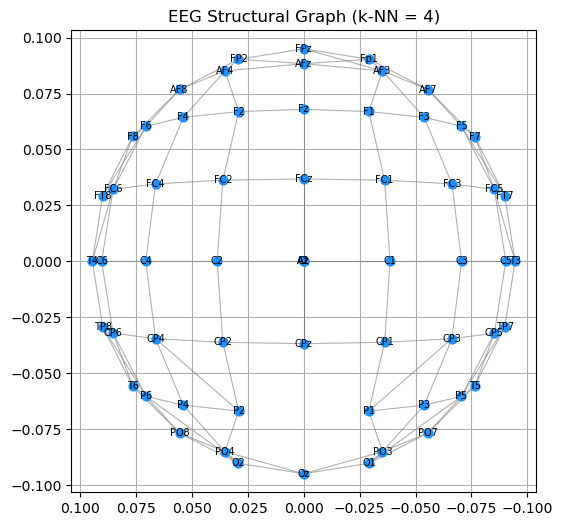

In [13]:
# Plot structural graph overlayed on 2D coords
x = coords[:, 0]
y = coords[:, 1]
plt.figure(figsize=(6, 6))
ei = edge_index.numpy()
for s, t in ei.T:
    plt.plot([x[s], x[t]], [y[s], y[t]], color="gray", alpha=0.4, linewidth=0.7)
plt.scatter(x, y, c="dodgerblue", s=40, zorder=3)
for i, ch in enumerate(channels_used):
    plt.text(x[i], y[i], ch, fontsize=7, ha="center", va="center")
plt.gca().invert_xaxis()
plt.axis("equal")
plt.title("EEG Structural Graph (k-NN = 4)")
plt.grid(True)
plt.show()

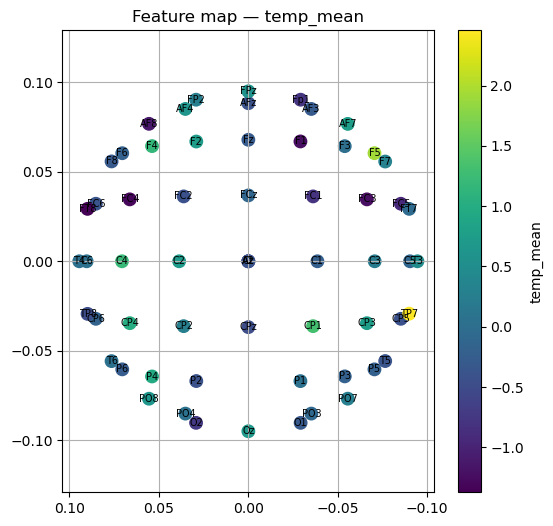

In [14]:
# Example: map a single feature across electrodes
epoch_id = 0
feat_idx = 0
feat_name = feature_cols[feat_idx]
feat = X_epochs[epoch_id][:, feat_idx].numpy()
plt.figure(figsize=(6, 6))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=feat, cmap="viridis", s=80)
plt.colorbar(sc, label=feat_name)
for i, ch in enumerate(channels_used):
    plt.text(coords[i, 0], coords[i, 1], ch, fontsize=7, ha="center", va="center")
plt.title(f"Feature map — {feat_name}")
plt.gca().invert_xaxis()
plt.axis("equal")
plt.grid(True)
plt.show()

## TEST

In [15]:
from collections import Counter
from sklearn.model_selection import train_test_split
import numpy as np
import torch

# 1) prendo un soggetto
target_subj = 0
mask = [m["subject_id"] == target_subj for m in meta_epochs]

X_subj = [X_epochs[i] for i, ok in enumerate(mask) if ok]
y_subj = [y_epochs[i] for i, ok in enumerate(mask) if ok]

# 2) filtro classi con almeno 2 esempi
cnt = Counter(y_subj)
valid_idx = [i for i, y in enumerate(y_subj) if cnt[y] >= 2]

X_valid = [X_subj[i] for i in valid_idx]
y_valid = [y_subj[i] for i in valid_idx]

print("Campioni validi:", len(X_valid))

# 3) RIMAPPO le label in 0..C-1
unique_labels = sorted(set(y_valid))
label_old2new = {old: new for new, old in enumerate(unique_labels)}

y_valid_enc = [label_old2new[y] for y in y_valid]
y_valid_enc = np.array(y_valid_enc)

n_classes = len(unique_labels)
print("n_classes:", n_classes)

# 4) split (1 stratificato, 1 no)
idx_all = np.arange(len(X_valid))

idx_train, idx_tmp = train_test_split(
    idx_all,
    test_size=0.3,
    stratify=y_valid_enc,
    random_state=42
)

idx_val, idx_test = train_test_split(
    idx_tmp,
    test_size=0.5,
    random_state=42
)

print("Train:", len(idx_train), "Val:", len(idx_val), "Test:", len(idx_test))

# 5) costruisco tensori feature medie
X_vec = torch.stack([x.mean(dim=0) for x in X_valid])   # [N, 40]
y_vec = torch.tensor(y_valid_enc, dtype=torch.long)     # [N]

X_train = X_vec[idx_train]
X_val   = X_vec[idx_val]
X_test  = X_vec[idx_test]

y_train = y_vec[idx_train]
y_val   = y_vec[idx_val]
y_test  = y_vec[idx_test]

Campioni validi: 550
n_classes: 110
Train: 385 Val: 82 Test: 83


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# =====================================================
# 1) PREPARA X_vec e y_vec (features e labels)
# =====================================================

import numpy as np

# X_t, y_t sono quelli dopo normalizzazione e portati su device
X_cpu = X_t.cpu().numpy()
y_cpu = y_t.cpu().numpy()

classes = np.unique(y_cpu)
print("Num classi:", len(classes))

train_idx_list = []
val_idx_list   = []
test_idx_list  = []

rng = np.random.RandomState(42)

for c in classes:
    idx_c = np.where(y_cpu == c)[0]
    rng.shuffle(idx_c)

    if len(idx_c) < 5:
        # fallback se qualche classe ha meno di 5 (non è il tuo caso ora)
        # ad esempio: 2 train, 1 val, il resto test
        n_train = max(1, len(idx_c) - 2)
        n_val   = 1
        train_idx  = idx_c[:n_train]
        val_idx    = idx_c[n_train:n_train+n_val]
        test_idx   = idx_c[n_train+n_val:]
    else:
        # caso normale: 5 per classe -> 3 train, 1 val, 1 test
        train_idx = idx_c[:3]
        val_idx   = idx_c[3:4]
        test_idx  = idx_c[4:5]

    train_idx_list.append(train_idx)
    val_idx_list.append(val_idx)
    test_idx_list.append(test_idx)

train_idx = np.concatenate(train_idx_list)
val_idx   = np.concatenate(val_idx_list)
test_idx  = np.concatenate(test_idx_list)

print("Train:", len(train_idx), "| Val:", len(val_idx), "| Test:", len(test_idx))

# crea i tensor finali
X_train = X_t[train_idx]
X_val   = X_t[val_idx]
X_test  = X_t[test_idx]

y_train = y_t[train_idx]
y_val   = y_t[val_idx]
y_test  = y_t[test_idx]

# =====================================================
# 3) MODELLO MLP BASE
# =====================================================

class MLP(nn.Module):
    def __init__(self, d_in, d_hid, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_hid),
            nn.ReLU(),
            nn.Linear(d_hid, n_classes)
        )
    def forward(self, x):
        return self.net(x)

d_in = X_train.shape[1]
n_classes = int(y.max().item()) + 1

model = MLP(d_in=d_in, d_hid=128, n_classes=n_classes).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def accuracy(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

# =====================================================
# 4) TRAINING + EARLY STOPPING BASE
# =====================================================

best_val_acc = 0
patience = 10
wait = 0

epochs = 80

for epoch in range(1, epochs+1):
    # train
    model.train()
    logits = model(X_train)
    loss = loss_fn(logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # val
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val)
        val_loss = loss_fn(val_logits, y_val)
        val_acc = accuracy(val_logits, y_val)

    print(f"Epoch {epoch:02d} | "
          f"train loss: {loss.item():.3f} | "
          f"val loss: {val_loss.item():.3f} | "
          f"val acc: {val_acc:.3f}")

    # early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model.state_dict()
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break

# =====================================================
# 5) TEST
# =====================================================

model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_acc = accuracy(test_logits, y_test)

print(f"\nTest accuracy: {test_acc:.3f}")

Device: cpu
Num classi: 110
Train: 330 | Val: 110 | Test: 110
Epoch 01 | train loss: 4.738 | val loss: 4.710 | val acc: 0.018
Epoch 02 | train loss: 4.713 | val loss: 4.712 | val acc: 0.018
Epoch 03 | train loss: 4.689 | val loss: 4.716 | val acc: 0.018
Epoch 04 | train loss: 4.665 | val loss: 4.720 | val acc: 0.009
Epoch 05 | train loss: 4.642 | val loss: 4.724 | val acc: 0.009
Epoch 06 | train loss: 4.619 | val loss: 4.729 | val acc: 0.009
Epoch 07 | train loss: 4.597 | val loss: 4.735 | val acc: 0.009
Epoch 08 | train loss: 4.575 | val loss: 4.741 | val acc: 0.009
Epoch 09 | train loss: 4.554 | val loss: 4.747 | val acc: 0.009
Epoch 10 | train loss: 4.532 | val loss: 4.754 | val acc: 0.009
Epoch 11 | train loss: 4.511 | val loss: 4.762 | val acc: 0.009
Early stopping.

Test accuracy: 0.000


# Clustering

In [ ]:
!pip install sentence_transformers -q  

In [19]:
true_labels = [
    "arrivare","andare","aspettare","avere","capire","chiamare","chiedere",
    "conoscere","dare","dire","dovere","essere","fare","mettere","potere",
    "prendere","sapere","sentire","trovare","venire","aprire","chiudere",
    "mangiare","bere","accendere","spegnere","volere","bene","si","no",
    "più","poco","molto","sempre","adesso","poi","male","sopra","sotto",
    "destra","sinistra","avanti","indietro","oggi","domani","ieri","forse",
    "prima","perchè","anche","come","però","quindi","quando","dove","se",
    "oppure","io","lui","lei","noi","voi","loro","tu","questo","quello",
    "buono","bello","cattivo","brutto","grande","piccolo","nuovo","vecchio",
    "cosa","parte","anno","casa","problema","aiuto","tempo","lavoro",
    "persona","acqua","cibo","bisogno","donna","uomo","gruppo","guerra",
    "idea","macchina","mano","oggetto","telefono","computer","domanda",
    "uno","mille","paura","ansia","gioia","felicità","tristezza",
    "serenità","amore","morte","bagno","dolore","riposo"
]

# 1) embeddings semantici con Sentence-BERT multilingua
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

emb = model.encode(true_labels, normalize_embeddings=True)   # [num_words, dim]


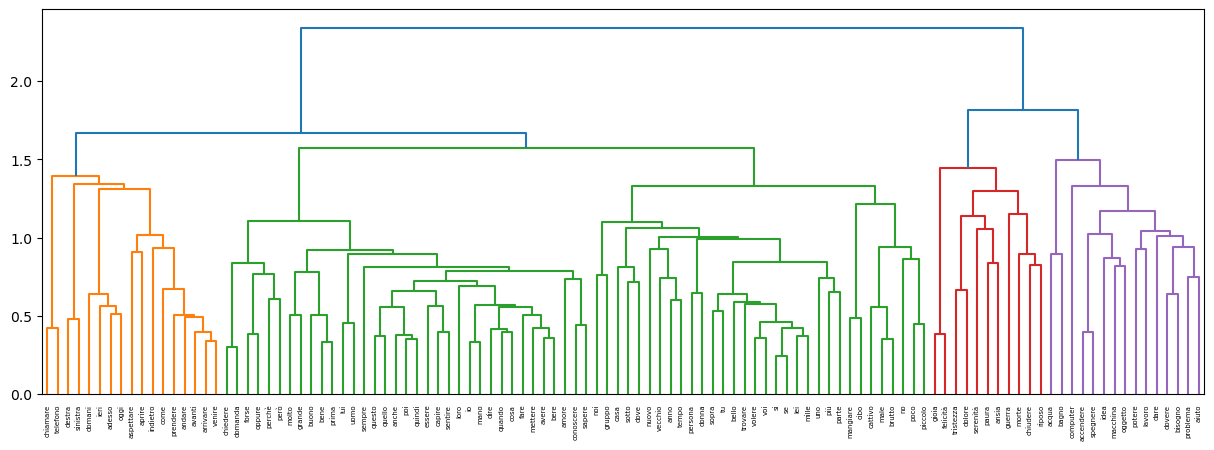


=== CLUSTER 0 ===
arrivare, andare, aspettare, chiamare, prendere, venire, aprire, adesso, destra, sinistra, avanti, indietro, oggi, domani, ieri, come, telefono

=== CLUSTER 1 ===
avere, capire, chiedere, conoscere, dire, essere, fare, mettere, sapere, sentire, trovare, mangiare, bere, volere, bene, si, no, più, poco, molto, sempre, poi, male, sopra, sotto, forse, prima, perchè, anche, però, quindi, quando, dove, se, oppure, io, lui, lei, noi, voi, loro, tu, questo, quello, buono, bello, cattivo, brutto, grande, piccolo, nuovo, vecchio, cosa, parte, anno, casa, tempo, persona, cibo, donna, uomo, gruppo, mano, domanda, uno, mille, amore

=== CLUSTER 3 ===
dare, dovere, potere, accendere, spegnere, problema, aiuto, lavoro, acqua, bisogno, idea, macchina, oggetto, computer, bagno

=== CLUSTER 2 ===
chiudere, guerra, paura, ansia, gioia, felicità, tristezza, serenità, morte, dolore, riposo


In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from collections import defaultdict

# embeddings
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
emb = model.encode(true_labels, normalize_embeddings=True)

# 1) clustering gerarchico
Z = linkage(emb, method="ward")
plt.figure(figsize=(15,5))
dendrogram(Z, labels=true_labels, leaf_rotation=90)
plt.show()

# 2) taglia l'albero in modo da avere ESATTAMENTE 4 cluster
cluster_ids = fcluster(Z, t=4, criterion="maxclust")  # cluster_id = 1..4
cluster_ids = cluster_ids - 1  # opzionale: 0..3

# 3) raggruppa parole per cluster e stampa
cluster2words = defaultdict(list)
for w, c in zip(true_labels, cluster_ids):
    cluster2words[c].append(w)

for c, words in cluster2words.items():
    print(f"\n=== CLUSTER {c} ===")
    print(", ".join(words))

In [21]:
true_labels = [
    "arrivare","andare","aspettare","avere","capire","chiamare","chiedere",
    "conoscere","dare","dire","dovere","essere","fare","mettere","potere",
    "prendere","sapere","sentire","trovare","venire","aprire","chiudere",
    "mangiare","bere","accendere","spegnere","volere","bene","si","no",
    "più","poco","molto","sempre","adesso","poi","male","sopra","sotto",
    "destra","sinistra","avanti","indietro","oggi","domani","ieri","forse",
    "prima","perchè","anche","come","però","quindi","quando","dove","se",
    "oppure","io","lui","lei","noi","voi","loro","tu","questo","quello",
    "buono","bello","cattivo","brutto","grande","piccolo","nuovo","vecchio",
    "cosa","parte","anno","casa","problema","aiuto","tempo","lavoro",
    "persona","acqua","cibo","bisogno","donna","uomo","gruppo","guerra",
    "idea","macchina","mano","oggetto","telefono","computer","domanda",
    "uno","mille","paura","ansia","gioia","felicità","tristezza",
    "serenità","amore","morte","bagno","dolore","riposo",
]

from sentence_transformers import SentenceTransformer
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import KMeans
from collections import defaultdict
import numpy as np
import json

# ------------------------------------------------------------------
# 1) Embedding delle parole (se non li hai già in memoria)
# ------------------------------------------------------------------
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
emb = model.encode(true_labels, normalize_embeddings=True)   # [num_words, dim]

# ------------------------------------------------------------------
# 2) Clustering gerarchico -> 4 cluster "grossi" (come prima)
# ------------------------------------------------------------------
Z = linkage(emb, method="ward")
cluster_ids_4 = fcluster(Z, t=4, criterion="maxclust")  # 1..4
cluster_ids_4 = cluster_ids_4 - 1                       # 0..3

# Per riferimento, stampiamo i 4 cluster
cluster2words_4 = defaultdict(list)
for w, c in zip(true_labels, cluster_ids_4):
    cluster2words_4[c].append(w)

print("=== CLUSTER A 4 CLASSI ===")
for c, words in cluster2words_4.items():
    print(f"\nCLUSTER {c}:")
    print(", ".join(words))

# ------------------------------------------------------------------
# 3) Splitta SOLO il cluster 1 in 2 sottocluster (k=2)
# ------------------------------------------------------------------
# indici delle parole che stanno nel cluster 1
idx_c1 = [i for i, c in enumerate(cluster_ids_4) if c == 1]

# embedding delle parole dentro il cluster 1
emb_c1 = emb[idx_c1]

# KMeans con 2 sottocluster
k_sub = 2
km_sub = KMeans(n_clusters=k_sub, random_state=42, n_init=10)
sub_ids = km_sub.fit_predict(emb_c1)   # valori 0 o 1

# mappa: indice della parola -> sottocluster (0 o 1)
sub_map = {idx_c1[j]: int(sub_ids[j]) for j in range(len(idx_c1))}

# ------------------------------------------------------------------
# 4) Costruisci nuovi cluster "fini" (5 cluster totali)
# ------------------------------------------------------------------
# Scelta numerazione:
#  - 0: vecchio cluster 0 (movimento/spazio/tempo breve)
#  - 1: vecchio cluster 3 (bisogni/oggetti/compiti)
#  - 2: vecchio cluster 2 (emozioni/stati interni)
#  - 3: sottocluster 1A (dal vecchio cluster 1)
#  - 4: sottocluster 1B (dal vecchio cluster 1)

new_cluster_ids = np.zeros_like(cluster_ids_4)

for i, c in enumerate(cluster_ids_4):
    if c == 0:
        new_c = 0
    elif c == 3:
        new_c = 1
    elif c == 2:
        new_c = 2
    elif c == 1:
        # guardo a quale sottocluster appartiene questa parola
        sub = sub_map[i]   # 0 o 1
        if sub == 0:
            new_c = 3
        else:
            new_c = 4
    else:
        raise ValueError("Cluster inatteso:", c)

    new_cluster_ids[i] = new_c

# ------------------------------------------------------------------
# 5) Visualizza i cluster finali (5 classi)
# ------------------------------------------------------------------
cluster2words_5 = defaultdict(list)
for w, c in zip(true_labels, new_cluster_ids):
    cluster2words_5[c].append(w)

print("\n\n=== CLUSTER FINALI A 5 CLASSI ===")
for c, words in cluster2words_5.items():
    print(f"\nCLUSTER {c}:")
    print(", ".join(words))

# ------------------------------------------------------------------
# 6) Dizionario finale parola -> cluster_id
# ------------------------------------------------------------------
word2cluster_fine = {w: int(c) for w, c in zip(true_labels, new_cluster_ids)}

# Salva la mappatura su disco così può essere riutilizzata in altre celle/notebook
out_cluster_path = project_root / "data/interim/word2cluster_fine.json"
out_cluster_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_cluster_path, "w", encoding="utf-8") as f:
    json.dump(word2cluster_fine, f, ensure_ascii=False, indent=2)
print(f"Saved semantic cluster mapping to {out_cluster_path}")

print("\nEsempio mapping:")
for w in true_labels[:10]:
    print(w, "->", word2cluster_fine[w])


=== CLUSTER A 4 CLASSI ===

CLUSTER 0:
arrivare, andare, aspettare, chiamare, prendere, venire, aprire, adesso, destra, sinistra, avanti, indietro, oggi, domani, ieri, come, telefono

CLUSTER 1:
avere, capire, chiedere, conoscere, dire, essere, fare, mettere, sapere, sentire, trovare, mangiare, bere, volere, bene, si, no, più, poco, molto, sempre, poi, male, sopra, sotto, forse, prima, perchè, anche, però, quindi, quando, dove, se, oppure, io, lui, lei, noi, voi, loro, tu, questo, quello, buono, bello, cattivo, brutto, grande, piccolo, nuovo, vecchio, cosa, parte, anno, casa, tempo, persona, cibo, donna, uomo, gruppo, mano, domanda, uno, mille, amore

CLUSTER 3:
dare, dovere, potere, accendere, spegnere, problema, aiuto, lavoro, acqua, bisogno, idea, macchina, oggetto, computer, bagno

CLUSTER 2:
chiudere, guerra, paura, ansia, gioia, felicità, tristezza, serenità, morte, dolore, riposo


=== CLUSTER FINALI A 5 CLASSI ===

CLUSTER 0:
arrivare, andare, aspettare, chiamare, prendere, ven

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


## Semantic clustering of imagined words

To reduce the complexity of the decoding task (110 distinct words, 5 trials per word and subject) and to obtain neuro-cognitively meaningful targets, we grouped the words into a small set of semantic clusters.

### Step 1 – Semantic embeddings

We started from the list of 110 Italian words used in the imagined speech paradigm (e.g., *andare, casa, acqua, aiuto, amore, paura*).  
Each word was encoded into a semantic vector using a multilingual Sentence-BERT model (`paraphrase-multilingual-MiniLM-L12-v2`).  
These embeddings capture distributional semantic similarity: words that tend to occur in similar linguistic contexts are mapped to nearby points in the embedding space.

### Step 2 – Hierarchical clustering and 4 macro-clusters

On top of the embeddings we applied hierarchical clustering (Ward linkage) and inspected the dendrogram.  
The tree showed a clear structure with four major branches, which we interpreted as four macro-clusters:

1. **Movement / space / near time**  
   - Examples: *arrivare, andare, aspettare, venire, aprire, oggi, domani, ieri, destra, sinistra, avanti, indietro, telefono*.  
   - These words are mainly related to actions, spatial orientation and short-term temporal concepts.

2. **General and functional language**  
   - Examples: *avere, essere, fare, dire, sapere, si, no, più, poco, molto, io, tu, lui, noi, voi, loro, questo, quello, bello, brutto, grande, piccolo, cosa, anno, tempo, persona, domanda, uno, mille, amore*.  
   - This large cluster contains high-frequency verbs, function words (pronouns, adverbs, connectives) and generic abstract concepts.

3. **Objects, needs and instrumental actions**  
   - Examples: *dare, dovere, potere, accendere, spegnere, problema, aiuto, lavoro, acqua, bisogno, idea, macchina, oggetto, computer, bagno*.  
   - The words in this group mostly refer to concrete objects, resources, practical tasks and needs.

4. **Emotions and internal states**  
   - Examples: *paura, ansia, gioia, felicità, tristezza, serenità, morte, dolore, riposo, guerra*.  
   - This cluster aggregates emotional states, affective experiences and other internally oriented concepts.

These four clusters already provide a meaningful semantic structure that is compatible with different large-scale brain networks (motor/spatial, language and function words, object-related processing, emotional and affective processing).

### Step 3 – Refinement of the “general language” cluster

The “general and functional language” cluster (Cluster 1) was very large and heterogeneous, mixing:

- high-frequency content words (e.g., *persona, casa, tempo, lavoro*), and  
- strongly functional items (e.g., *se, però, quindi, quando, anche, io, tu, lui*).

To obtain a slightly finer granularity without exploding the number of classes, we refined only this cluster:

1. We selected the embeddings of the words belonging to Cluster 1.
2. We ran a K-means algorithm with *k = 2* on this subset.
3. We obtained two sub-clusters, which we treat as two separate classes in the final label space.

In the final configuration we therefore work with **5 semantic classes**:

1. **Movement / space / near time**  
2. **Objects, needs and instrumental actions**  
3. **Emotions and internal states**  
4. **General language – content-oriented subgroup** (subset of Cluster 1)  
5. **General language – function-oriented subgroup** (subset of Cluster 1)

The last two classes both derive from the original “general language” group, but they split words that are more content-like (nouns and verbs with clearer semantics) from those that are more function-like (pronouns, connectives, adverbs).  
This refinement keeps the number of classes low (5), but introduces a more informative semantic structure, which is useful both for interpretation and for downstream EEG decoding experiments.